<a href="https://colab.research.google.com/github/berradimeriemencg/DS2025/blob/main/Bienvenue_dans_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bienvenue dans Colab !

1. Bibliothèques importées avec succès.

2. Chargement du nouveau Dataset : Iris...
   Données chargées. Taille du dataset : (150, 5)
   Classes à prédire : ['setosa' 'versicolor' 'virginica']

3. Analyse Exploratoire et Visualisation (EDA)...


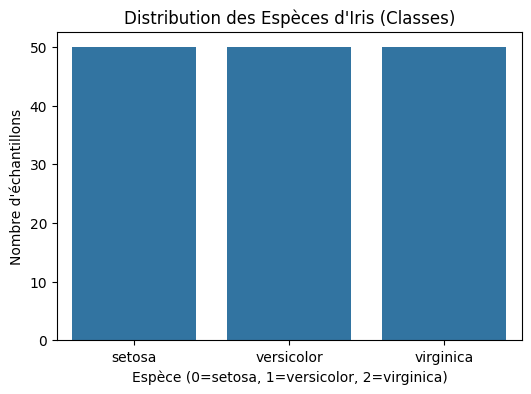

   Visualisation des relations entre les mesures...


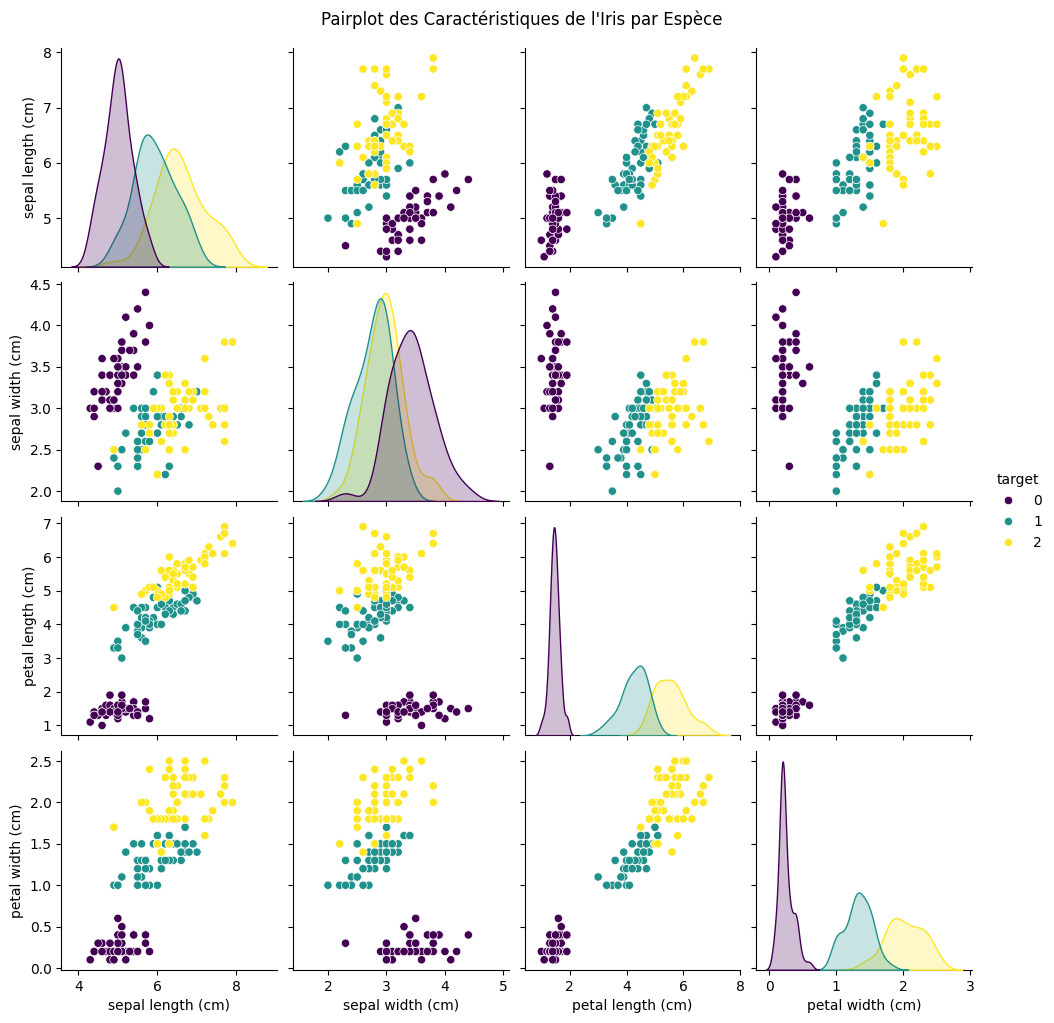

4. Pré-traitement des données : Standardisation...
   Données prêtes. Taille du jeu d'entraînement : (105, 4)

5. Entraînement du Modèle (Arbre de Décision)...
   Modèle entraîné avec succès.

6. Évaluation des performances...
   >>> Accuracy Score : 91.11%

   >>> Rapport de Classification :
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.92      0.80      0.86        15
   virginica       0.82      0.93      0.88        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



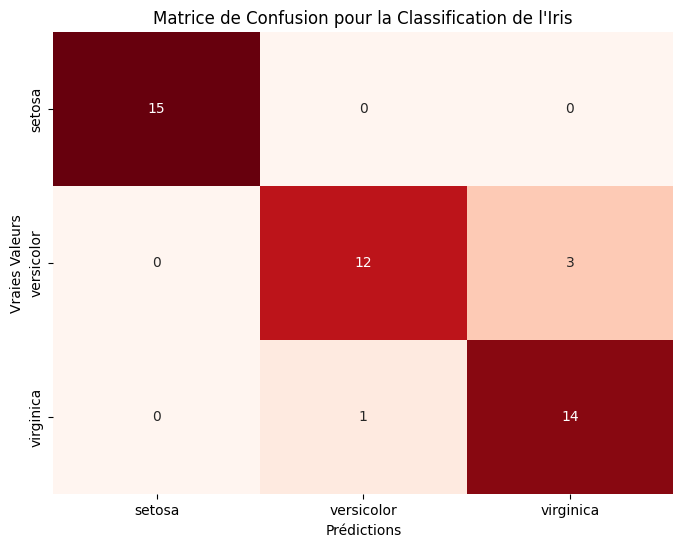


Fin de l'analyse et de la modélisation.


In [1]:
# ==============================================================================
# 1. IMPORTATION DES BIBLIOTHÈQUES
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importations spécifiques pour le Machine Learning
from sklearn.datasets import load_iris # Nouveau dataset : Iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier # Nouvel algorithme : Arbre de Décision
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("1. Bibliothèques importées avec succès.\n")

# ==============================================================================
# 2. CHARGEMENT DES DONNÉES (Nouveau Dataset : Iris)
# ==============================================================================
print("2. Chargement du nouveau Dataset : Iris...")

# Charger le dataset Iris, qui est intégré à scikit-learn
iris = load_iris(as_frame=True)
data = iris.frame # Le DataFrame principal
X = iris.data    # Les caractéristiques (features)
y = iris.target  # La cible (target: 0, 1 ou 2)

# Informations sur les classes
target_names = iris.target_names
print(f"   Données chargées. Taille du dataset : {data.shape}")
print(f"   Classes à prédire : {target_names}\n")

# ==============================================================================
# 3. ANALYSE EXPLORATOIRE ET VISUALISATION (EDA) - Nouveaux Graphes
# ==============================================================================
print("3. Analyse Exploratoire et Visualisation (EDA)...")

# A. Visualisation de la distribution des classes (similaire à l'ancien fichier)
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=data)
plt.title('Distribution des Espèces d\'Iris (Classes)')
plt.xlabel('Espèce (0=setosa, 1=versicolor, 2=virginica)')
plt.ylabel('Nombre d\'échantillons')
plt.xticks(ticks=[0, 1, 2], labels=target_names)
plt.show()

# B. Graphe de pairplot pour visualiser les relations entre les features (Nouveau Graphe)
print("   Visualisation des relations entre les mesures...")
sns.pairplot(data, hue='target', palette='viridis', diag_kind='kde')
plt.suptitle('Pairplot des Caractéristiques de l\'Iris par Espèce', y=1.02)
plt.show()


# ==============================================================================
# 4. PRÉ-TRAITEMENT DES DONNÉES (Scaling)
# ==============================================================================
# Le dataset Iris est très propre, nous n'avons besoin que de la Standardisation (Scaling)
print("4. Pré-traitement des données : Standardisation...")

# Séparer les données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Créer un transformateur (Scaler) pour la Standardisation
scaler = StandardScaler()

# Créer un pipeline simple pour appliquer le scaling
preprocessor = Pipeline(steps=[('scaler', scaler)])

# Appliquer le pré-traitement
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"   Données prêtes. Taille du jeu d'entraînement : {X_train_processed.shape}\n")

# ==============================================================================
# 5. ENTRAÎNEMENT DU MODÈLE (Decision Tree Classifier)
# ==============================================================================
print("5. Entraînement du Modèle (Arbre de Décision)...")

# Utilisation d'un Arbre de Décision, un modèle parfait pour Iris
classifier = DecisionTreeClassifier(random_state=42)

# Entraînement sur les données d'entraînement standardisées
classifier.fit(X_train_processed, y_train)

print("   Modèle entraîné avec succès.\n")

# ==============================================================================
# 6. ÉVALUATION ET PERFORMANCE
# ==============================================================================
print("6. Évaluation des performances...")

# Prédictions sur le jeu de test
y_pred = classifier.predict(X_test_processed)

# A. Accuracy (Précision globale)
acc = accuracy_score(y_test, y_pred)
print(f"   >>> Accuracy Score : {acc*100:.2f}%")

# B. Rapport détaillé (Similaire à l'ancien fichier)
print("\n   >>> Rapport de Classification :")
# On utilise la liste 'target_names' pour avoir les noms des classes au lieu des numéros
print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))

# C. Matrice de Confusion Visuelle (Nouveau Graphe)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Prédictions')
plt.ylabel('Vraies Valeurs')
plt.title('Matrice de Confusion pour la Classification de l\'Iris')
plt.show()


print("\nFin de l'analyse et de la modélisation.")